In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_fontja  # noqa: F401

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.clean import refine_data
from src.preprocessing.feature_engineering import engineer_features
from src.preprocessing.clean import preprocess_data

pd.set_option("display.max_columns", None)

In [2]:
# 前処理を施したデータフレームを用意
path = '../data/raw/Tokyo_20251_20254.csv'

df = preprocess_data(path)
df = engineer_features(df)
display(df.isna().sum())
display(df.head())

種類                0
価格情報区分            0
市区町村コード           0
最寄駅：名称            0
最寄駅：距離（分）         0
取引価格（総額）          0
面積（㎡）             0
建築年               0
建物の構造             0
用途                0
今後の利用目的           0
都市計画              0
建ぺい率（％）           0
容積率（％）            0
改装            27857
築年数               0
最寄駅：緯度          871
最寄駅：経度          871
住所                0
room_count     1120
has_L             0
has_D             0
has_K             0
has_S             0
取引四半期             0
log_面積            0
log_最寄駅：距離       88
築年数^2             0
中心地_距離          871
山手線内側             0
容積消化率（％）          0
log_建ぺい率          0
log_容積率           0
容積距離              0
dtype: int64

,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引四半期,log_面積,log_最寄駅：距離,築年数^2,中心地_距離,山手線内側,容積消化率（％）,log_建ぺい率,log_容積率,容積距離
0,中古マンション等,1,13101,小伝馬町,2.0,59000000,45,2014.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,12.0,35.690737,139.778433,東京都千代田区岩本町,1.0,1,1,1,0,1,3.806662,0.693147,144.0,1.469402,1,7.50,4.382027,6.39693,1200.0
1,中古マンション等,1,13101,岩本町,4.0,120000000,55,2023.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,3.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,1,4.007333,1.386294,9.0,1.775066,1,7.50,4.382027,6.39693,2400.0
2,中古マンション等,1,13101,岩本町,5.0,38000000,40,2007.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,19.0,35.695534,139.775866,東京都千代田区岩本町,1.0,0,1,1,0,1,3.688879,1.609438,361.0,1.775066,1,7.50,4.382027,6.39693,3000.0
3,中古マンション等,1,13101,岩本町,3.0,65000000,45,2016.0,RC,住宅,住宅,Unknown,80.0,600.0,NaN,10.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,1,3.806662,1.098612,100.0,1.775066,1,7.50,4.382027,6.39693,1800.0
4,中古マンション等,1,13101,市ケ谷,3.0,45000000,35,2005.0,鉄骨造,住宅,住宅,商業系,80.0,700.0,NaN,21.0,35.691000,139.735583,東京都千代田区九段北,1.0,0,0,1,0,1,3.555348,1.098612,441.0,3.048605,1,8.75,4.382027,6.55108,2100.0


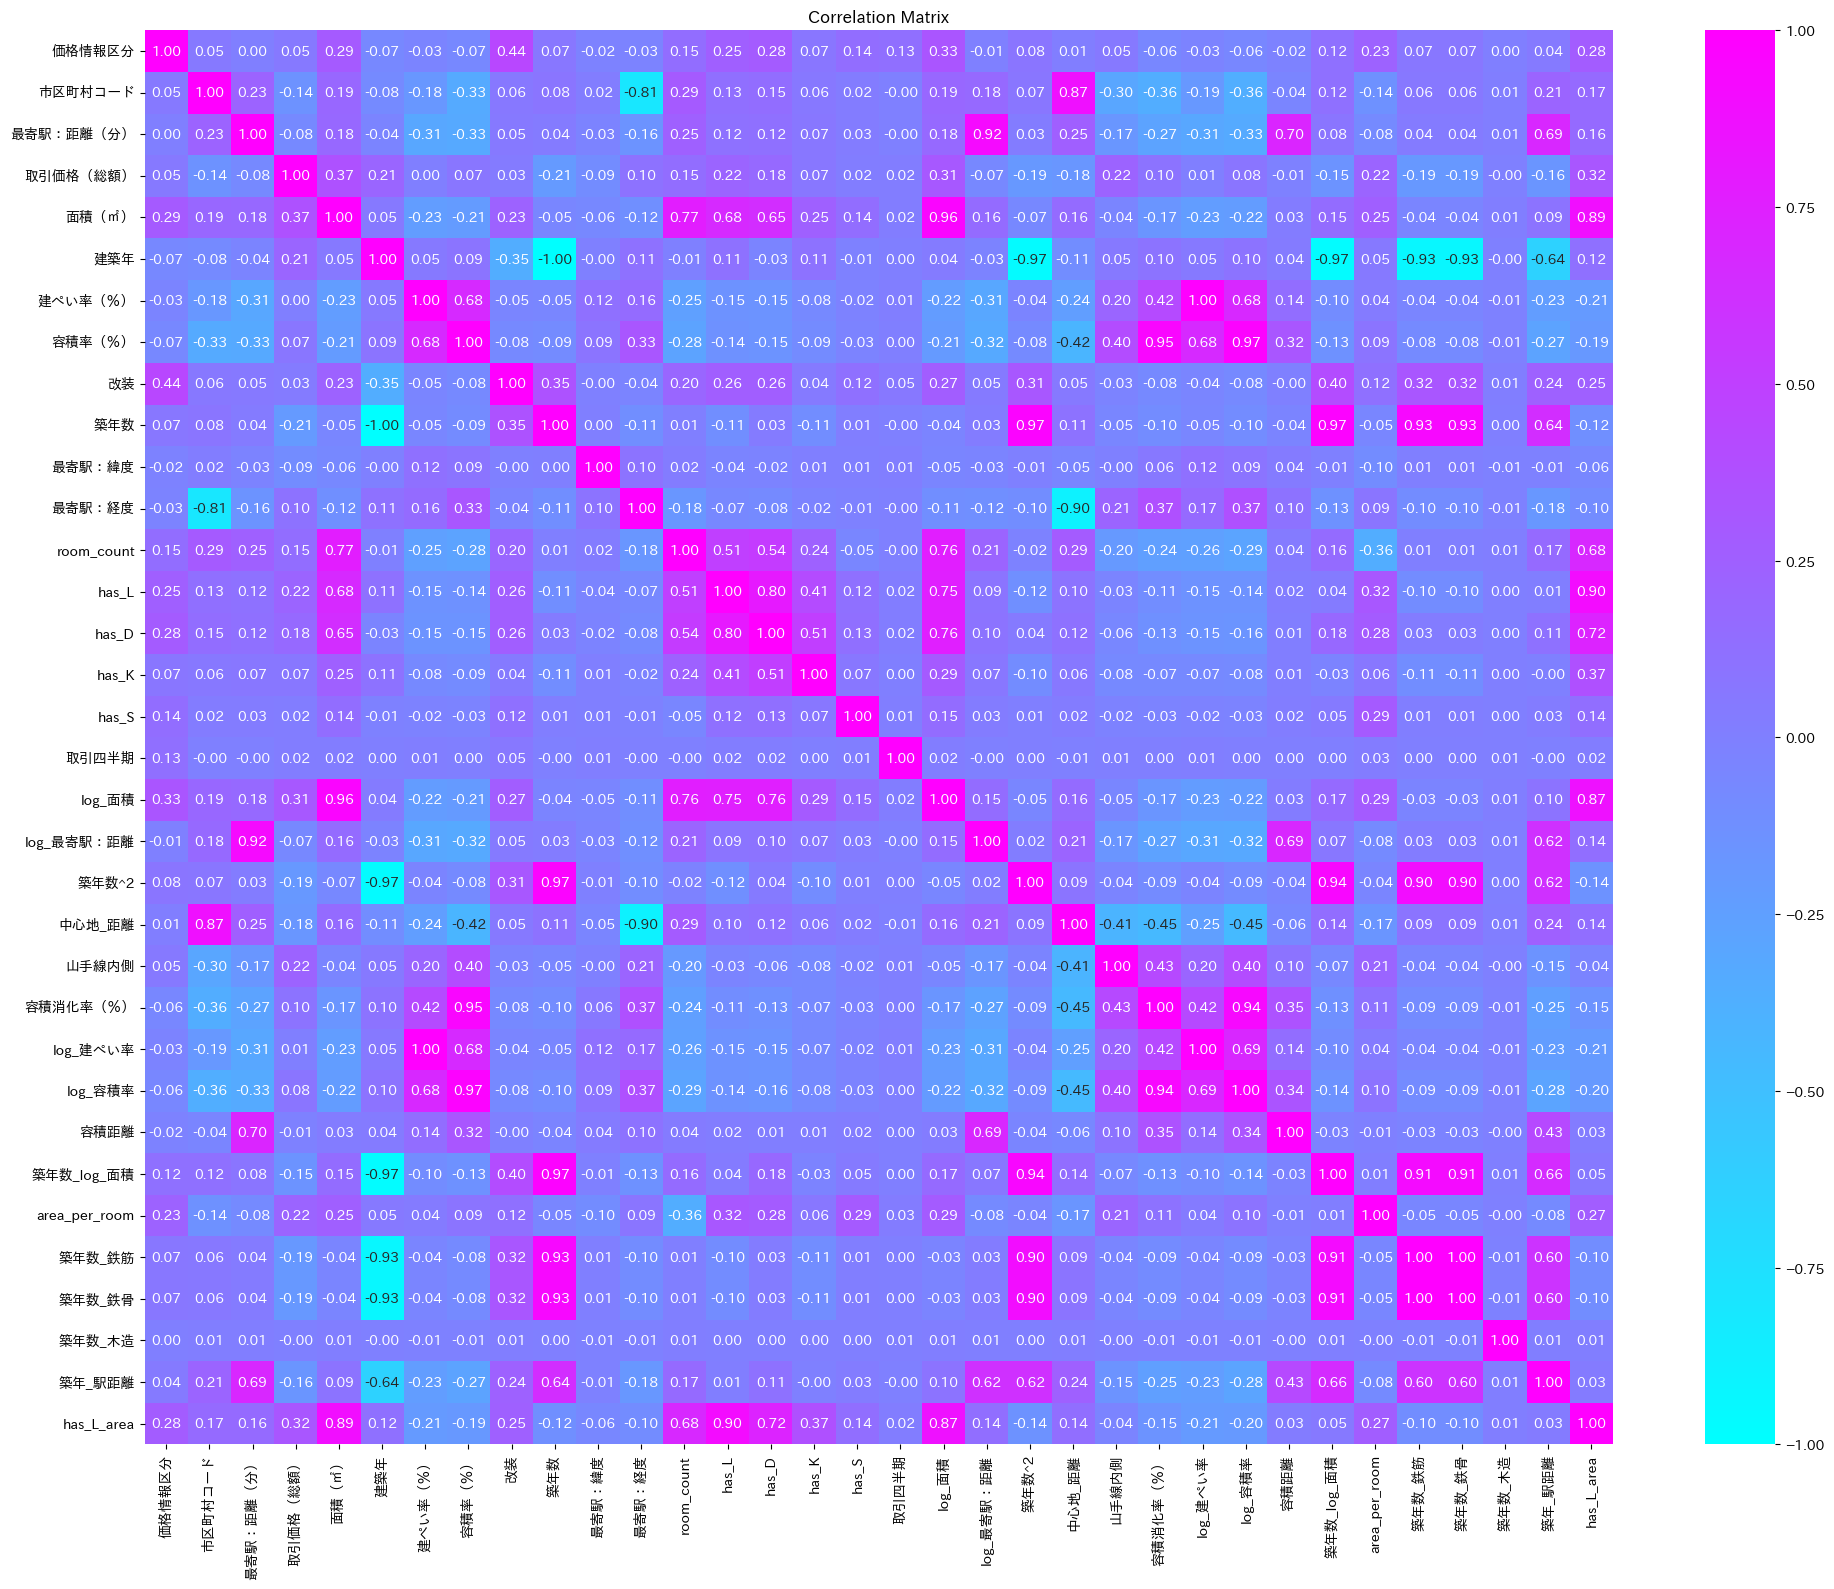

In [14]:
# 数値方特徴の相関分析
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="cool", ax=ax)
ax.set_title("Correlation Matrix")
fig.tight_layout()

# 画像を保存
output_dir = project_root / "outputs" / "figures"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(output_dir / "correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

In [4]:
# 築年数 * log_面積
df["築年数_log_面積"] = df["築年数"] * df["log_面積"]
display(df[["築年数", "面積（㎡）", "築年数_log_面積"]].head())

,築年数,面積（㎡）,築年数_log_面積
0,12.0,45,45.679950
1,3.0,55,12.022000
2,19.0,40,70.088710
3,10.0,45,38.066625
4,21.0,35,74.662309


In [5]:
# 築古ワンルームのフラグ
df["is_old_one_room"] = ((df["築年数"] >= 35) & (df["面積（㎡）"] <= 30) & (df["has_L"] == 0))
display(df[["築年数", "面積（㎡）", "has_L", "is_old_one_room"]].head())

# 築古1Kのフラグ
df["is_old_1K"] = ((df["築年数"] >= 35) & (df["面積（㎡）"] <= 40) & (df["has_L"] == 0) & (df["has_K"] == 1))
display(df[["築年数", "面積（㎡）", "has_L", "has_K", "is_old_1K"]].head())

,築年数,面積（㎡）,has_L,is_old_one_room
0,12.0,45,1,False
1,3.0,55,1,False
2,19.0,40,0,False
3,10.0,45,1,False
4,21.0,35,0,False


,築年数,面積（㎡）,has_L,has_K,is_old_1K
0,12.0,45,1,1,False
1,3.0,55,1,1,False
2,19.0,40,0,1,False
3,10.0,45,1,1,False
4,21.0,35,0,1,False


In [6]:
# 1部屋あたりの広さ（風呂トイレや玄関などの面積も含まれてしまう?）
df["area_per_room"] = df["面積（㎡）"] / df["room_count"].clip(lower=1)
display(df[["面積（㎡）", "room_count", "area_per_room"]].head())

,面積（㎡）,room_count,area_per_room
0,45,1.0,45.0
1,55,2.0,27.5
2,40,1.0,40.0
3,45,2.0,22.5
4,35,1.0,35.0


In [7]:
print(df["建物の構造"].value_counts())

建物の構造
RC         29305
SRC         9374
Unknown      528
鉄骨造          389
SRC、RC        22
RC、鉄骨造        18
軽量鉄骨造         17
木造             3
SRC、鉄骨造        2
ブロック造          1
Name: count, dtype: int64


In [8]:
# 築年数×構造ダミー
is_concreate = df["建物の構造"].isin({"RC", "SRC", "SRC、RC"})
is_steel = df["建物の構造"].isin({"鉄骨造", "SRC、鉄骨造"})
is_wood = df["建物の構造"].eq("木造")

df["築年数_鉄筋"] = df["築年数"] * is_concreate.astype(int)
df["築年数_鉄骨"] = df["築年数"] * is_concreate.astype(int)
df["築年数_木造"] = df["築年数"] * is_wood.astype(int)

display(df[["築年数", "建物の構造", "築年数_鉄筋", "築年数_鉄骨", "築年数_木造"]].head())

,築年数,建物の構造,築年数_鉄筋,築年数_鉄骨,築年数_木造
0,12.0,RC,12.0,12.0,0.0
1,3.0,RC,3.0,3.0,0.0
2,19.0,RC,19.0,19.0,0.0
3,10.0,RC,10.0,10.0,0.0
4,21.0,鉄骨造,0.0,0.0,0.0


In [9]:
# 築年数×駅距離
df["築年_駅距離"] = df["築年数"] * df["最寄駅：距離（分）"]
display(df[["築年数", "最寄駅：距離（分）", "築年_駅距離"]].head())

,築年数,最寄駅：距離（分）,築年_駅距離
0,12.0,2.0,24.0
1,3.0,4.0,12.0
2,19.0,5.0,95.0
3,10.0,3.0,30.0
4,21.0,3.0,63.0


In [10]:
# 面積を階級化
df["area_category"] = pd.cut(
  df["面積（㎡）"], bins=[0, 20, 30, 50, 70, 90, np.inf],
  labels=["0-20", "20-30", "30-50", "50-70", "70-90", "90+"]
)

display(df[["面積（㎡）", "area_category"]].head())

,面積（㎡）,area_category
0,45,30-50
1,55,50-70
2,40,30-50
3,45,30-50
4,35,30-50


In [11]:
# 低面積フラグ
df["is_low_area"] = df["面積（㎡）"] <= 20
display(df[["面積（㎡）", "is_low_area"]].head())
print(df["is_low_area"].value_counts())

,面積（㎡）,is_low_area
0,45,False
1,55,False
2,40,False
3,45,False
4,35,False


is_low_area
False    35872
True      3787
Name: count, dtype: int64


In [12]:
# has_L × 面積
df["has_L_area"] = df["has_L"] * df["面積（㎡）"]
display(df[["has_L", "面積（㎡）", "has_L_area"]].head())

,has_L,面積（㎡）,has_L_area
0,1,45,45
1,1,55,55
2,0,40,0
3,1,45,45
4,0,35,0


In [16]:
# 築年数 × log_面積
df["築年数_log_面積"] = df["築年数"] * df["log_面積"]
display(df[["築年数", "log_面積", "築年数_log_面積"]].head())

,築年数,log_面積,築年数_log_面積
0,12.0,3.806662,45.679950
1,3.0,4.007333,12.022000
2,19.0,3.688879,70.088710
3,10.0,3.806662,38.066625
4,21.0,3.555348,74.662309


In [ ]:
df["is_old_one_room"] = ((df["築年数"] >= 35) & (df["面積（㎡）"] <= 25) & (df["has_L"] == 0))
display(df[["築年数", "面積（㎡）", "has_L", "is_old_one_room"]].head())
print(df["is_old_one_room"].value_counts())

,築年数,面積（㎡）,has_L,is_old_one_room
0,12.0,45,1,False
1,3.0,55,1,False
2,19.0,40,0,False
3,10.0,45,1,False
4,21.0,35,0,False


is_old_one_room
False    37287
True      2372
Name: count, dtype: int64


In [21]:
df["is_old_1K"] = ((df["築年数"] >= 35) & (df["面積（㎡）"] <= 30) & (df["has_K"] == 1))
display(df[["築年数", "面積（㎡）", "has_K", "is_old_1K"]].head())

,築年数,面積（㎡）,has_K,is_old_1K
0,12.0,45,1,False
1,3.0,55,1,False
2,19.0,40,1,False
3,10.0,45,1,False
4,21.0,35,1,False


In [22]:
df["area_per_room"] = df["面積（㎡）"] / df["room_count"].clip(lower=1)
display(df[["面積（㎡）", "room_count", "area_per_room"]].head())

,面積（㎡）,room_count,area_per_room
0,45,1.0,45.0
1,55,2.0,27.5
2,40,1.0,40.0
3,45,2.0,22.5
4,35,1.0,35.0


In [23]:
df["has_L_area"] = df["has_L"] * df["面積（㎡）"]
display(df[["has_L", "面積（㎡）", "has_L_area"]].head())

,has_L,面積（㎡）,has_L_area
0,1,45,45
1,1,55,55
2,0,40,0
3,1,45,45
4,0,35,0


In [27]:
df["築年数_鉄筋"] = df["築年数"] * is_concreate
display(df[["築年数", "建物の構造", "築年数_鉄筋"]].head())

,築年数,建物の構造,築年数_鉄筋
0,12.0,RC,12.0
1,3.0,RC,3.0
2,19.0,RC,19.0
3,10.0,RC,10.0
4,21.0,鉄骨造,0.0


In [28]:
df["築年数_鉄骨"] = df["築年数"] * is_steel
display(df[["築年数", "建物の構造", "築年数_鉄骨"]].head())

,築年数,建物の構造,築年数_鉄骨
0,12.0,RC,0.0
1,3.0,RC,0.0
2,19.0,RC,0.0
3,10.0,RC,0.0
4,21.0,鉄骨造,21.0


In [ ]:
df["築年数_木造"] = df["築年数"] * is_wood
display(df[["築年数", "建物の構造", "築年数_木造"]].head())

,築年数,建物の構造,築年数_木造
0,12.0,RC,0.0
1,3.0,RC,0.0
2,19.0,RC,0.0
3,10.0,RC,0.0
4,21.0,鉄骨造,0.0


In [30]:
df["築年_駅距離"] = df["築年数"] * df["最寄駅：距離（分）"]
display(df[["築年数", "最寄駅：距離（分）", "築年_駅距離"]].head())

,築年数,最寄駅：距離（分）,築年_駅距離
0,12.0,2.0,24.0
1,3.0,4.0,12.0
2,19.0,5.0,95.0
3,10.0,3.0,30.0
4,21.0,3.0,63.0


In [31]:
df["area_category"] = pd.cut(
  df["面積（㎡）"], bins=[0, 20, 30, 50, 70, 90, np.inf],
  labels=["0-20", "20-30", "30-50", "50-70", "70-90", "90+"]
)
display(df[["面積（㎡）", "area_category"]].head())

,面積（㎡）,area_category
0,45,30-50
1,55,50-70
2,40,30-50
3,45,30-50
4,35,30-50


In [35]:
df["is_low_area"] = df["面積（㎡）"] < 20
print(df["is_low_area"].value_counts())

is_low_area
False    38739
True       920
Name: count, dtype: int64


In [37]:
df["山手線内側_log_面積"] = df["山手線内側"] * df["log_面積"]
display(df[["山手線内側", "log_面積", "山手線内側_log_面積"]].head())

,山手線内側,log_面積,山手線内側_log_面積
0,1,3.806662,3.806662
1,1,4.007333,4.007333
2,1,3.688879,3.688879
3,1,3.806662,3.806662
4,1,3.555348,3.555348
